# 06 · Check — `m2_unit.py`, the one-unit version of notebooks 01–04

## Executive summary (read this first)

`f1_pipeline/m2_unit.py` packs notebooks 01 → 04 into plain functions that take **one unit folder**.
`forecast_agent.py`'s `build_draws()` calls them for F1 level cards. This notebook runs each function on
one unit so you can see what it returns, then checks the results against the files notebooks 03 and 04
saved:

| step | function | returns |
|---|---|---|
| 1 | `read_unit(unit_dir)` | card fields + the wide panel |
| 2 | `build_features(unit)` | one table per (asset, horizon): features at each origin, the h-step target |
| 3 | `fit_m2(cell)` | anchor, μ, σ, the calibration constant, the ε pool, the coefficients |
| 4 | `report(unit, fits)` | the same three tables notebook 03 saves, for one unit |
| 5 | `draw_joint(fits, …)` | notebook 04's joint draws |

**Pass condition:** §6 and §7 show a maximum absolute difference of **0** against notebooks 03 and 04 on
every unit. §8 shows `build_draws()` takes the M2 path on an F1 level card and falls back to the random
walk on a log-return card.

No realized outcomes are read anywhere in this notebook.

## 0 — Setup

Change `UNIT` to look at a different card.

In [1]:
import importlib, json, pathlib, sys, tomllib
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "f1_pipeline" else pathlib.Path.cwd() / "f1_pipeline"
REPO, DATA = HERE.parent, HERE / "data"
for p in (str(HERE), str(REPO)):
    if p not in sys.path: sys.path.insert(0, p)
import m2_unit as m2; importlib.reload(m2)

pd.set_option("display.width", 210); pd.set_option("display.max_columns", 40)
INK, INK2, GRID, M2C = "#0b0b0b", "#52514e", "#e6e5e1", "#1baf7a"
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})

UNIT = "t2-F1-pause-2006"          # two assets x two horizons: shows the joint part
UNIT_DIR = REPO / "units" / UNIT
print("module :", m2.__file__)
print("unit   :", UNIT_DIR.relative_to(REPO))
print("config :", dict(lam_mu=m2.LAM_MU, lam_sig=m2.LAM_SIG, winsor=m2.WINSOR,
                       sigma_clamp=m2.SIGMA_CLAMP, mu_clamp_sigmas=m2.MU_CLAMP_SIGMAS))

module : /Users/dew/agenton/track2-forecasting-public/f1_pipeline/m2_unit.py
unit   : units/t2-F1-pause-2006
config : {'lam_mu': 10.0, 'lam_sig': 10.0, 'winsor': 4.0, 'sigma_clamp': (0.25, 4.0), 'mu_clamp_sigmas': 3.0}


## 1 — `read_unit`: the card and the panel

In [2]:
unit = m2.read_unit(UNIT_DIR)
print(pd.Series({"unit": unit.unit, "panel": unit.panel, "freq": unit.freq, "asof": unit.asof.date(),
                 "assets": unit.assets, "horizons": unit.horizons, "target_type": unit.target_type,
                 "value_unit": unit.value_unit, "panel rows": len(unit.wide),
                 "panel span": f"{unit.wide.index[0].date()} -> {unit.wide.index[-1].date()}",
                 "series": list(unit.wide.columns)}).to_string())
unit.wide.tail()

unit                                            t2-F1-pause-2006
panel                                                rates_daily
freq                                                       daily
asof                                                  2006-08-08
assets                                         [UST_2Y, UST_10Y]
horizons                                              [126, 189]
target_type                                                level
value_unit                                     percent_per_annum
panel rows                                                  1650
panel span                              2000-01-03 -> 2006-08-08
series         [UST_10Y, UST_20Y, UST_2Y, UST_30Y, UST_5Y, US...


asset,UST_10Y,UST_20Y,UST_2Y,UST_30Y,UST_5Y,UST_7Y
date,,,,,,
2006-08-02,4.96,5.14,4.97,5.05,4.88,4.90
2006-08-03,4.96,5.13,4.98,5.04,4.90,4.91
2006-08-04,4.91,5.09,4.91,5.00,4.84,4.85
2006-08-07,4.93,5.09,4.96,5.00,4.86,4.87
2006-08-08,4.93,5.11,4.91,5.02,4.85,4.86


## 2 — `build_features`: one table per cell

Each row is an **origin** date. `split = train` rows have an observed h-step target; the single
`split = predict` row is the as-of. Features are kept if they are non-NaN somewhere in the train rows
(notebook 02's rule), then split into the **mean** group (drives μ) and the **scale** group (drives σ).

In [3]:
cells_ = m2.build_features(unit)
pd.DataFrame([{"asset": c.asset, "horizon": c.horizon, "steps_ahead": c.steps,
               "train rows": int((c.frame.split == "train").sum()),
               "predict rows": int((c.frame.split == "predict").sum()),
               "first origin": c.frame.origin_date.iloc[0].date(), "as-of row": c.frame.origin_date.iloc[-1].date(),
               "mean feats": sum(not m2.is_scale_feature(f) for f in c.features),
               "scale feats": sum(m2.is_scale_feature(f) for f in c.features)} for c in cells_])

,asset,horizon,steps_ahead,train rows,predict rows,first origin,as-of row,mean feats,scale feats
0,UST_2Y,126,126,1524,1,2000-01-03,2006-08-08,13,8
1,UST_2Y,189,189,1461,1,2000-01-03,2006-08-08,13,8
2,UST_10Y,126,126,1524,1,2000-01-03,2006-08-08,13,8
3,UST_10Y,189,189,1461,1,2000-01-03,2006-08-08,13,8


In [4]:
c0 = cells_[0]
print(f"{c0.asset} h{c0.horizon} — mean features : {[f for f in c0.features if not m2.is_scale_feature(f)]}")
print(f"{' ' * len(c0.asset)}       scale features: {[f for f in c0.features if m2.is_scale_feature(f)]}")
print("\nthe as-of row (what the fit predicts from):")
c0.frame[c0.frame.split == "predict"].T.rename(columns=lambda _: "as-of")

UST_2Y h126 — mean features : ['level', 'mom_21', 'mom_63', 'mom_126', 'mom_252', 'z_252', 'pos_252', 'last_step', 'ctx_slope_10_2', 'ctx_slope_5_2', 'ctx_ust2y', 'ctx_ust10y', 'ctx_slope_mom_63']
             scale features: ['log_level', 'rv_21', 'rv_63', 'rv_252', 'ewma_vol', 'vol_ratio', 'skew_252', 'ctx_curv_2_5_10']

the as-of row (what the fit predicts from):


,as-of
origin_date,2006-08-08 00:00:00
origin_idx,1649
horizon_bd,126
steps_ahead,126
target_date,2007-01-31 00:00:00
split,predict
anchor,4.91
target,NaN
target_change,NaN
level,4.91


## 3 — `fit_m2`: anchor, μ, σ

Fitted on every train row whose outcome was observed by the as-of. The forecast centre is
`anchor + μ`; σ is the width of the change. `sigma_const` is the plain RMS residual — both clamps are
relative to it (σ within ¼–4×, |μ| ≤ 3×).

In [5]:
fits = [m2.fit_m2(c) for c in cells_]
predictions, pools, coefs = m2.report(unit, fits)
predictions[["asset", "horizon_bd", "asof_row", "n_train", "anchor", "mu", "centre", "sigma",
             "sigma_const", "calib_c", "n_eps"]].round({c: 4 for c in ("anchor", "mu", "centre", "sigma",
                                                                       "sigma_const", "calib_c")})

,asset,horizon_bd,asof_row,n_train,anchor,mu,centre,sigma,sigma_const,calib_c,n_eps
0,UST_2Y,126,2006-08-08,1272,4.91,0.0552,4.9652,0.6918,0.6775,1.5592,1272
1,UST_2Y,189,2006-08-08,1209,4.91,0.0713,4.9813,0.8421,0.8062,1.5807,1209
2,UST_10Y,126,2006-08-08,1272,4.93,-0.0514,4.8786,0.4719,0.4878,1.7168,1272
3,UST_10Y,189,2006-08-08,1209,4.93,-0.0772,4.8528,0.4640,0.5142,2.0677,1209


In [6]:
# the clamps: is either one binding on this unit?
chk = predictions.assign(sigma_over_const=predictions.sigma / predictions.sigma_const,
                         mu_over_const=predictions.mu / predictions.sigma_const)
chk["sigma clamped"] = ~chk.sigma_over_const.between(m2.SIGMA_CLAMP[0] + 1e-9, m2.SIGMA_CLAMP[1] - 1e-9)
chk["mu clamped"] = chk.mu_over_const.abs() >= m2.MU_CLAMP_SIGMAS - 1e-9
chk[["asset", "horizon_bd", "sigma_over_const", "mu_over_const", "sigma clamped", "mu clamped"]].round(3)

,asset,horizon_bd,sigma_over_const,mu_over_const,sigma clamped,mu clamped
0,UST_2Y,126,1.021,0.081,False,False
1,UST_2Y,189,1.045,0.088,False,False
2,UST_10Y,126,0.967,-0.105,False,False
3,UST_10Y,189,0.902,-0.150,False,False


In [7]:
# coefficients on standardised features: the biggest movers of mu and of log-variance
top = (coefs.assign(abs_coef=coefs.coef.abs())
            .sort_values("abs_coef", ascending=False)
            .groupby(["asset", "horizon_bd", "model"]).head(4))
top.pivot_table(index=["asset", "horizon_bd", "model", "feature"], values="coef").round(4)

coef
asset   horizon_bd model feature                
UST_10Y 126        mu    ctx_slope_5_2   -0.0146
                         ctx_ust10y      -0.0260
                         level           -0.0260
                         mom_63          -0.0133
                   sigma ctx_curv_2_5_10  0.0319
                         rv_21           -0.0145
                         skew_252         0.0243
                         vol_ratio       -0.0215
        189        mu    ctx_slope_10_2  -0.0124
                         ctx_slope_5_2   -0.0177
                         ctx_ust10y      -0.0301
                         level           -0.0301
                   sigma ctx_curv_2_5_10  0.0200
                         rv_21            0.0180
                         skew_252         0.0308
                         vol_ratio        0.0203
UST_2Y  126        mu    ctx_ust10y      -0.0439
                         mom_252          0.0301
                         pos_252          0.0291
                         z_252            0.0292
                   sigma log_level        0.0397
                         rv_63            0.0172
                         skew_252        -0.0685
                         vol_ratio        0.0066
        189        mu    ctx_ust10y      -0.0536
                         mom_252          0.0476
                         pos_252          0.0423
                         z_252            0.0465
                   sigma log_level        0.0566
                         rv_21            0.0103
                         skew_252        -0.0521
                         vol_ratio        0.0218

## 4 — The ε pool: the distribution's shape

`eps = r / σ` for each training origin. By construction `mean(eps²) ≈ 1` before the σ clamp. Heavy tails
here are what the model carries into the forecast instead of assuming a normal.

In [8]:
q = pools.groupby(["asset", "horizon_bd"]).eps
summary = pd.DataFrame({"n": q.size(), "mean": q.mean(), "sd": q.std(), "mean eps^2": q.apply(lambda s: (s**2).mean()),
                        "skew": q.skew(), "excess kurt": q.apply(lambda s: s.kurt()),
                        "q01": q.quantile(0.01), "q99": q.quantile(0.99),
                        "first": q.apply(lambda s: pools.loc[s.index, "origin_date"].min().date()),
                        "last": q.apply(lambda s: pools.loc[s.index, "origin_date"].max().date())})
summary.round(3)

n   mean   sd  mean eps^2   skew  excess kurt    q01    q99       first        last
asset   horizon_bd                                                                                        
UST_10Y 126         1272  0.003  1.0         1.0 -0.458       -0.205 -2.768  1.755  2001-01-03  2006-02-07
        189         1209  0.019  1.0         1.0 -0.589       -0.087 -2.400  1.853  2001-01-03  2005-11-03
UST_2Y  126         1272  0.018  1.0         1.0 -0.618       -0.552 -2.428  1.556  2001-01-03  2006-02-07
        189         1209  0.029  1.0         1.0 -0.664       -0.492 -2.246  1.636  2001-01-03  2005-11-03

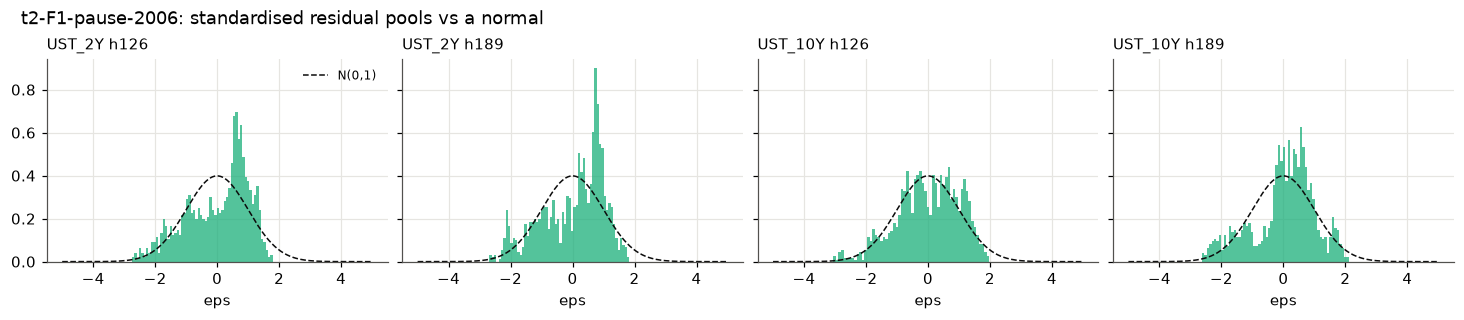

In [9]:
fig, axes = plt.subplots(1, len(fits), figsize=(3.3 * len(fits), 2.8), layout="constrained", sharey=True)
xs = np.linspace(-5, 5, 300)
for ax, f in zip(np.atleast_1d(axes), fits):
    ax.hist(f.eps.clip(-5, 5), bins=60, density=True, color=M2C, alpha=.75)
    ax.plot(xs, np.exp(-xs**2 / 2) / np.sqrt(2 * np.pi), color=INK, lw=1, ls="--", label="N(0,1)")
    ax.set_title(f"{f.asset} h{f.horizon}", fontsize=10); ax.set_xlabel("eps")
np.atleast_1d(axes)[0].legend(fontsize=8)
fig.suptitle(f"{UNIT}: standardised residual pools vs a normal", x=0.01, ha="left"); plt.show()

## 5 — `draw_joint`: the forecast

`value = anchor + μ + σ · eps(d)`, with **one historical date `d` per draw shared by every cell**. The
correlation table below should be strongly positive between cells — that is the dependence the
variogram term scores.

In [10]:
N_DRAWS, SEED = 2000, 2024          # notebook 04's settings
S = m2.draw_joint(fits, N_DRAWS, SEED)
labels = [f"{f.asset} h{f.horizon}" for f in fits]
qs = np.quantile(S, [0.01, 0.05, 0.5, 0.95, 0.99], axis=0)
display(pd.DataFrame({"anchor": [f.anchor for f in fits], "centre": [f.anchor + f.mu for f in fits],
                      "draw mean": S.mean(0), "q01": qs[0], "q05": qs[1], "median": qs[2], "q95": qs[3], "q99": qs[4]},
                     index=labels).round(4))
pd.DataFrame(np.corrcoef(S.T), index=labels, columns=labels).round(3)

,anchor,centre,draw mean,q01,q05,median,q95,q99
UST_2Y h126,4.91,4.9652,4.9466,3.2272,3.6355,5.1069,5.8674,6.0754
UST_2Y h189,4.91,4.9813,5.0021,3.0861,3.2823,5.2438,6.0580,6.3301
UST_10Y h126,4.93,4.8786,4.8427,3.5519,3.9864,4.8506,5.5067,5.6620
UST_10Y h189,4.93,4.8528,4.8575,3.7447,3.9067,4.9319,5.6121,5.7189


,UST_2Y h126,UST_2Y h189,UST_10Y h126,UST_10Y h189
UST_2Y h126,1.000,0.825,0.822,0.547
UST_2Y h189,0.825,1.000,0.582,0.761
UST_10Y h126,0.822,0.582,1.000,0.629
UST_10Y h189,0.547,0.761,0.629,1.000


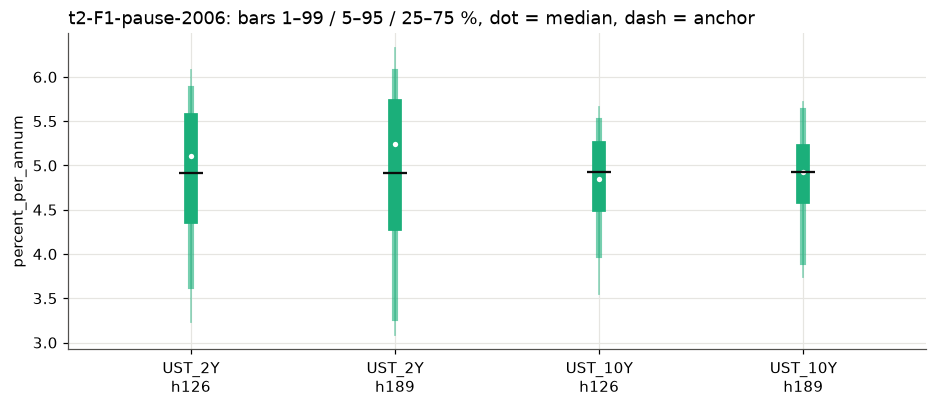

In [11]:
fig, ax = plt.subplots(figsize=(1.6 * len(fits) + 2, 3.6), layout="constrained")
for j, f in enumerate(fits):
    q = np.quantile(S[:, j], [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    ax.plot([j, j], [q[0], q[6]], color=M2C, lw=1.2, alpha=.45)
    ax.plot([j, j], [q[1], q[5]], color=M2C, lw=4, alpha=.6)
    ax.plot([j, j], [q[2], q[4]], color=M2C, lw=9)
    ax.plot(j, q[3], "o", color="white", mec=M2C, ms=5, mew=1.5)
    ax.plot(j, f.anchor, "_", color=INK, ms=16, mew=1.5)
ax.set_xticks(range(len(fits)), [l.replace(" ", "\n") for l in labels]); ax.set_xlim(-.6, len(fits) - .4)
ax.set_ylabel(unit.value_unit[:30])
ax.set_title(f"{UNIT}: bars 1–99 / 5–95 / 25–75 %, dot = median, dash = anchor"); plt.show()

## 6 — Check against notebook 03, every unit

Runs `read_unit → build_features → fit_m2 → report` on each level unit and compares with
`data/f1_predictions.parquet`, `data/f1_residual_pools.parquet` and `data/f1_coefficients.parquet`.
Needs those files, which notebook 03 writes.

In [12]:
P = pd.read_parquet(DATA / "f1_predictions.parquet")
E = pd.read_parquet(DATA / "f1_residual_pools.parquet")
C = pd.read_parquet(DATA / "f1_coefficients.parquet")

rows = []
for u in sorted(P.unit.unique()):
    _, _, pr, po, co = m2.run_unit(REPO / "units" / u)
    ref = P[P.unit == u].set_index(["asset", "horizon_bd"]); new = pr.set_index(["asset", "horizon_bd"]).loc[ref.index]
    a = E[E.unit == u].set_index(["asset", "horizon_bd", "origin_date"]).eps.sort_index()
    b = po.set_index(["asset", "horizon_bd", "origin_date"]).eps.sort_index()
    ca = C[C.unit == u].set_index(["asset", "horizon_bd", "model", "feature"]).coef.sort_index()
    cb = co.set_index(["asset", "horizon_bd", "model", "feature"]).coef.sort_index()
    rows.append({"unit": u, "cells": len(new),
                 **{k: float((new[k] - ref[k]).abs().max()) for k in ("anchor", "mu", "sigma", "sigma_const", "calib_c")},
                 "n_train same": bool((new.n_train == ref.n_train).all()),
                 "eps dates same": a.index.equals(b.index), "eps": float((a - b.reindex(a.index)).abs().max()),
                 "coef names same": ca.index.equals(cb.index), "coef": float((ca - cb.reindex(ca.index)).abs().max())})
check03 = pd.DataFrame(rows).set_index("unit")
num = check03.select_dtypes("number").drop(columns="cells")
print(f"{len(check03)} units, {check03.cells.sum()} cells — max |difference| over everything: {num.max().max():.1e}")
print("all index/count checks true:", bool(check03.select_dtypes(bool).all().all()))
check03

21 units, 41 cells — max |difference| over everything: 0.0e+00
all index/count checks true: True


,cells,anchor,mu,sigma,sigma_const,calib_c,n_train same,eps dates same,eps,coef names same,coef
unit,,,,,,,,,,,
t2-F1-aud-on-hold-2016,2,0.0,0.0,0.0,0.0,0.0,True,True,0.0,True,0.0
t2-F1-cad-boc-2017,2,0.0,0.0,0.0,0.0,0.0,True,True,0.0,True,0.0
t2-F1-chf-highly-valued-2021,2,0.0,0.0,0.0,0.0,0.0,True,True,0.0,True,0.0
t2-F1-conflicting-texts-2024,2,0.0,0.0,0.0,0.0,0.0,True,True,0.0,True,0.0
t2-F1-considerable-period-2003,2,0.0,0.0,0.0,0.0,0.0,True,True,0.0,True,0.0
t2-F1-conundrum-2005,2,0.0,0.0,0.0,0.0,0.0,True,True,0.0,True,0.0
t2-F1-cpi-glidepath-2023,2,0.0,0.0,0.0,0.0,0.0,True,True,0.0,True,0.0
t2-F1-dkk-peg-2019,1,0.0,0.0,0.0,0.0,0.0,True,True,0.0,True,0.0
t2-F1-eur-range-2017,2,0.0,0.0,0.0,0.0,0.0,True,True,0.0,True,0.0


## 7 — Check against notebook 04's forecasts

`draw_joint` with notebook 04's seed and draw count should reproduce each
`units/<unit>/forecast/forecast.parquet` exactly.

In [13]:
rows = []
for u in sorted(P.unit.unique()):
    fc = REPO / "units" / u / "forecast" / "forecast.parquet"
    if not fc.exists():
        rows.append({"unit": u, "max |diff|": np.nan, "note": "no notebook-04 forecast on disk"}); continue
    un = m2.read_unit(REPO / "units" / u)
    fs = [m2.fit_m2(c) for c in m2.build_features(un)]
    Sd = m2.draw_joint(fs, N_DRAWS, SEED)
    ref = pd.read_parquet(fc)
    d = max(float(np.abs(ref[(ref.asset == f.asset) & (ref.horizon == f.horizon)].sort_values("draw").value.to_numpy()
                         - Sd[:, j]).max()) for j, f in enumerate(fs))
    rows.append({"unit": u, "max |diff|": d, "note": ""})
check04 = pd.DataFrame(rows).set_index("unit")
print(f"max |draw_joint - notebook 04| over all units: {check04['max |diff|'].max():.1e}")
check04

max |draw_joint - notebook 04| over all units: 0.0e+00


,max |diff|,note
unit,,
t2-F1-aud-on-hold-2016,0.0,
t2-F1-cad-boc-2017,0.0,
t2-F1-chf-highly-valued-2021,0.0,
t2-F1-conflicting-texts-2024,0.0,
t2-F1-considerable-period-2003,0.0,
t2-F1-conundrum-2005,0.0,
t2-F1-cpi-glidepath-2023,0.0,
t2-F1-dkk-peg-2019,0.0,
t2-F1-eur-range-2017,0.0,


## 8 — Through `forecast_agent.build_draws()`

What the submission actually calls. On an F1 **level** card it takes the M2 path; on a **log-return**
card, or any other family, it keeps the random walk. `_last_base` records which one ran.

In [14]:
import forecast_agent as fa; importlib.reload(fa)

def run_agent(u, n_draws=N_DRAWS, seed=SEED):
    card = tomllib.loads((REPO / "units" / u / "card.toml").read_text()); t = card["targets"]
    assets, horizons = [str(a) for a in t["asset_ids"]], [int(h) for h in t["horizons"]]
    neutral = {a: {"shift": 0.0, "widen": 1.0, "skew": 0.0} for a in assets}
    out = fa.build_draws(fa._read_panels(REPO / "units" / u), assets, horizons, card["provenance"]["data_cutoff"],
                         neutral, n_draws, seed, target_type=t["target_type"], family=card["metadata"]["category"])
    return out, fa._last_base, t["target_type"], card["metadata"]["category"]

out, base, tt, fam = run_agent(UNIT)
print(f"{UNIT}: family {fam}, target {tt} -> base = {base}, shape {out.shape}")
print(f"  equals draw_joint above: {np.array_equal(out.reshape(N_DRAWS, -1), S)}")

log_units = sorted(p.parent.name for p in (REPO / "units").glob("t2-F1-*/card.toml")
                   if tomllib.loads(p.read_text())["targets"]["target_type"] != "level")
for u in log_units:
    _, base, tt, fam = run_agent(u, n_draws=500, seed=0)
    print(f"{u}: family {fam}, target {tt} -> base = {base}")

t2-F1-pause-2006: family T2-F1, target level -> base = M2, shape (2000, 2, 2)
  equals draw_joint above: True
t2-F1-ai-mom-2024: family T2-F1, target log_return -> base = random walk
t2-F1-fed-put-2019: family T2-F1, target log_return -> base = random walk


In [15]:
# text adjustments on the M2 path: shift moves every draw, widen scales the spread around the centre
card = tomllib.loads((UNIT_DIR / "card.toml").read_text()); t = card["targets"]
assets, horizons = [str(a) for a in t["asset_ids"]], [int(h) for h in t["horizons"]]
adj = {a: {"shift": 0.10, "widen": 1.5, "skew": 0.0} for a in assets}
tilted = fa.build_draws(fa._read_panels(UNIT_DIR), assets, horizons, card["provenance"]["data_cutoff"], adj,
                        N_DRAWS, SEED, target_type="level", family="T2-F1").reshape(N_DRAWS, -1)
centre = np.array([f.anchor + f.mu for f in fits])
expect = centre + 0.10 + 1.5 * (S - centre)
print(f"shift=+0.10, widen=1.5 matches centre + shift + 1.5 x (plain draw - centre): "
      f"max |diff| = {np.abs(tilted - expect).max():.1e}")

shift=+0.10, widen=1.5 matches centre + shift + 1.5 x (plain draw - centre): max |diff| = 1.8e-15


## 9 — Where this leaves things

- `m2_unit.py` reproduces notebooks 03 and 04 exactly (§6, §7).
- `build_draws()` uses it for F1 level cards and keeps the random walk elsewhere (§8).
- Known limit, from notebook 03 §4.1: below ~1,000 training rows M2 is worse than the random walk.
  The three short units (2003, 2004, 2005) sit there; `n_train` in §6 shows which.